# JWST NIRCam PSFs

Generate 67x67 pixel PSFs for each NIRCam wide filter using `STPSFEngine`.

In [4]:
import sys
sys.path.insert(0, '/nfshome/bwedig/mejiro')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from mejiro.engines.stpsf_engine import STPSFEngine

In [5]:
import os

WIDE_FILTERS = ['F070W', 'F090W', 'F115W', 'F150W', 'F200W', 'F277W', 'F356W', 'F444W']
NUM_PIX = 67
OVERSAMPLE = 1
OUTPUT_DIR = '/data/bwedig/mejiro/nircam_psfs'

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [6]:
psfs = {}

for filt in WIDE_FILTERS:
    print(f'Generating PSF for {filt}...')
    psf = STPSFEngine.get_jwst_psf(filt, oversample=OVERSAMPLE, num_pix=NUM_PIX)
    psfs[filt] = psf
    print(f'  shape: {psf.shape}')

print('Done.')

Generating PSF with STPSF, which may be slow. Consider caching frequently-used PSFs.


Generating PSF for F070W...


Generating PSF with STPSF, which may be slow. Consider caching frequently-used PSFs.


  shape: (67, 67)
Generating PSF for F090W...


Generating PSF with STPSF, which may be slow. Consider caching frequently-used PSFs.


...

  shape: (67, 67)
Generating PSF for F277W...


Generating PSF with STPSF, which may be slow. Consider caching frequently-used PSFs.


  shape: (67, 67)
Generating PSF for F356W...


Generating PSF with STPSF, which may be slow. Consider caching frequently-used PSFs.


  shape: (67, 67)
Generating PSF for F444W...
  shape: (67, 67)
Done.


In [7]:
for filt, psf in psfs.items():
    path = os.path.join(OUTPUT_DIR, f'{filt}.npy')
    np.save(path, psf)
    print(f'Saved {path}')

Saved /data/bwedig/mejiro/nircam_psfs/F070W.npy
Saved /data/bwedig/mejiro/nircam_psfs/F090W.npy
Saved /data/bwedig/mejiro/nircam_psfs/F115W.npy
Saved /data/bwedig/mejiro/nircam_psfs/F150W.npy
Saved /data/bwedig/mejiro/nircam_psfs/F200W.npy
Saved /data/bwedig/mejiro/nircam_psfs/F277W.npy
Saved /data/bwedig/mejiro/nircam_psfs/F356W.npy
Saved /data/bwedig/mejiro/nircam_psfs/F444W.npy


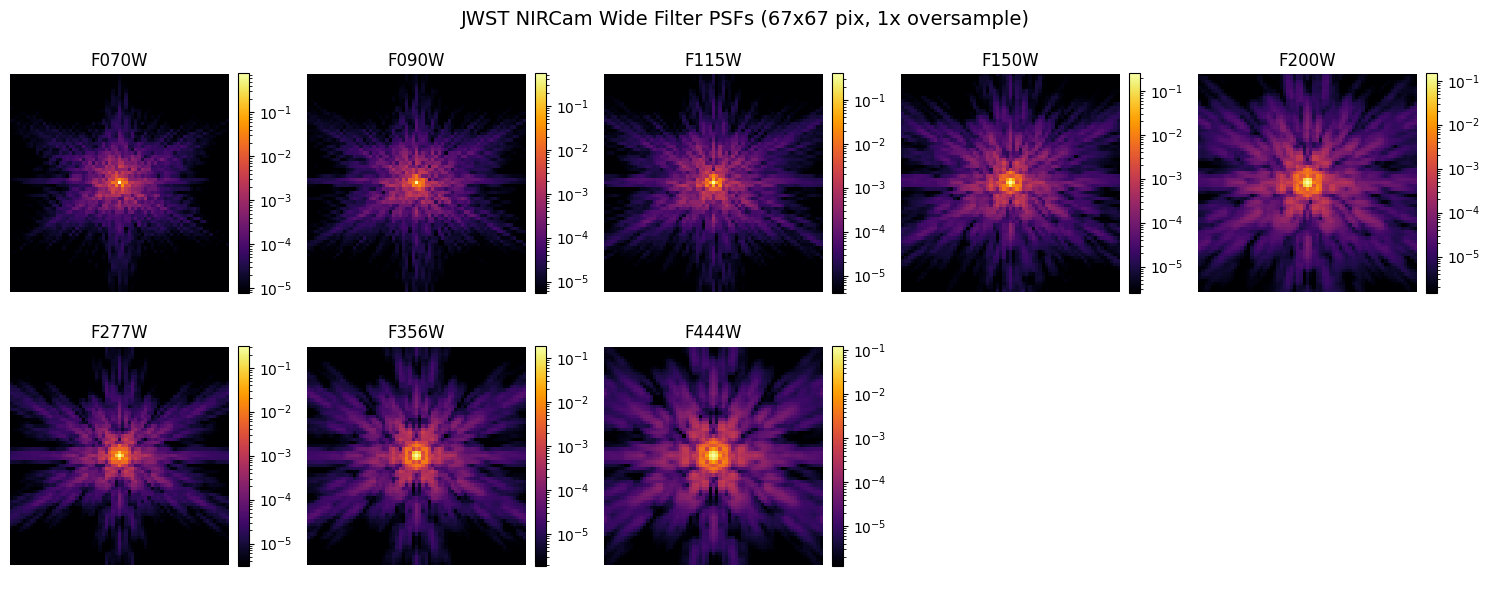

In [8]:
n_filters = len(WIDE_FILTERS)
ncols = 5
nrows = (n_filters + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
axes = axes.flatten()

for i, filt in enumerate(WIDE_FILTERS):
    psf = psfs[filt]
    im = axes[i].imshow(psf, norm=LogNorm(vmin=psf.max() * 1e-5, vmax=psf.max()), cmap='inferno', origin='lower')
    axes[i].set_title(filt)
    axes[i].axis('off')
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle(f'JWST NIRCam Wide Filter PSFs ({NUM_PIX}x{NUM_PIX} pix, {OVERSAMPLE}x oversample)', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
print(f'{'Filter':<10} {'Shape':<20} {'Min':<12} {'Max':<12} {'Sum':<12}')
print('-' * 66)
for filt, psf in psfs.items():
    print(f'{filt:<10} {str(psf.shape):<20} {psf.min():<12.4e} {psf.max():<12.4e} {psf.sum():<12.4f}')

Filter     Shape                Min          Max          Sum         
------------------------------------------------------------------
F070W      (67, 67)             3.2767e-07   7.7390e-01   1.3434      
F090W      (67, 67)             4.2279e-07   5.4804e-01   1.0296      
F115W      (67, 67)             3.1637e-07   3.9873e-01   0.9744      
F150W      (67, 67)             2.3793e-07   2.4850e-01   0.9682      
F200W      (67, 67)             9.7763e-08   1.4707e-01   0.9602      
F277W      (67, 67)             8.3374e-08   3.1532e-01   0.9751      
F356W      (67, 67)             7.8405e-08   1.8972e-01   0.9681      
F444W      (67, 67)             1.0473e-07   1.2695e-01   0.9612      
